In [1]:
pip install nycflights13

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [3]:
from nycflights13 import flights, airlines, airports, planes, weather

df=flights.copy()
print("Flights shape:", df.shape)
display(df.head())

C:\Users\hp\New folder\Lib\site-packages\nycflights13\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename as _rf


Flights shape: (336776, 19)


,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01T10:00:00Z
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01T11:00:00Z


Basic data understanding

### FLIGHTS

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            336776 non-null  int64  
 1   month           336776 non-null  int64  
 2   day             336776 non-null  int64  
 3   dep_time        328521 non-null  float64
 4   sched_dep_time  336776 non-null  int64  
 5   dep_delay       328521 non-null  float64
 6   arr_time        328063 non-null  float64
 7   sched_arr_time  336776 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         336776 non-null  object 
 10  flight          336776 non-null  int64  
 11  tailnum         334264 non-null  object 
 12  origin          336776 non-null  object 
 13  dest            336776 non-null  object 
 14  air_time        327346 non-null  float64
 15  distance        336776 non-null  int64  
 16  hour            336776 non-null  int64  
 17  minute    

In [5]:
df.describe(include ="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,336776.0,NaN,NaN,NaN,2013.0,0.0,2013.0,2013.0,2013.0,2013.0,2013.0
month,336776.0,NaN,NaN,NaN,6.54851,3.414457,1.0,4.0,7.0,10.0,12.0
day,336776.0,NaN,NaN,NaN,15.710787,8.768607,1.0,8.0,16.0,23.0,31.0
dep_time,328521.0,NaN,NaN,NaN,1349.109947,488.281791,1.0,907.0,1401.0,1744.0,2400.0
sched_dep_time,336776.0,NaN,NaN,NaN,1344.25484,467.335756,106.0,906.0,1359.0,1729.0,2359.0
dep_delay,328521.0,NaN,NaN,NaN,12.63907,40.210061,-43.0,-5.0,-2.0,11.0,1301.0
arr_time,328063.0,NaN,NaN,NaN,1502.054999,533.264132,1.0,1104.0,1535.0,1940.0,2400.0
sched_arr_time,336776.0,NaN,NaN,NaN,1536.38022,497.457142,1.0,1124.0,1556.0,1945.0,2359.0
arr_delay,327346.0,NaN,NaN,NaN,6.895377,44.633292,-86.0,-17.0,-5.0,14.0,1272.0
carrier,336776,16,UA,58665,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing-value analysis

In [6]:
missing = pd.DataFrame({"missing_count":df.isna().sum(),
                       "missing_percent":(df.isna().sum()/len(df)* 100).round(2)}).sort_values("missing_count",ascending=False)

missing.head(15)

,missing_count,missing_percent
arr_delay,9430,2.80
air_time,9430,2.80
arr_time,8713,2.59
dep_time,8255,2.45
dep_delay,8255,2.45
tailnum,2512,0.75
year,0,0.00
origin,0,0.00
minute,0,0.00
hour,0,0.00


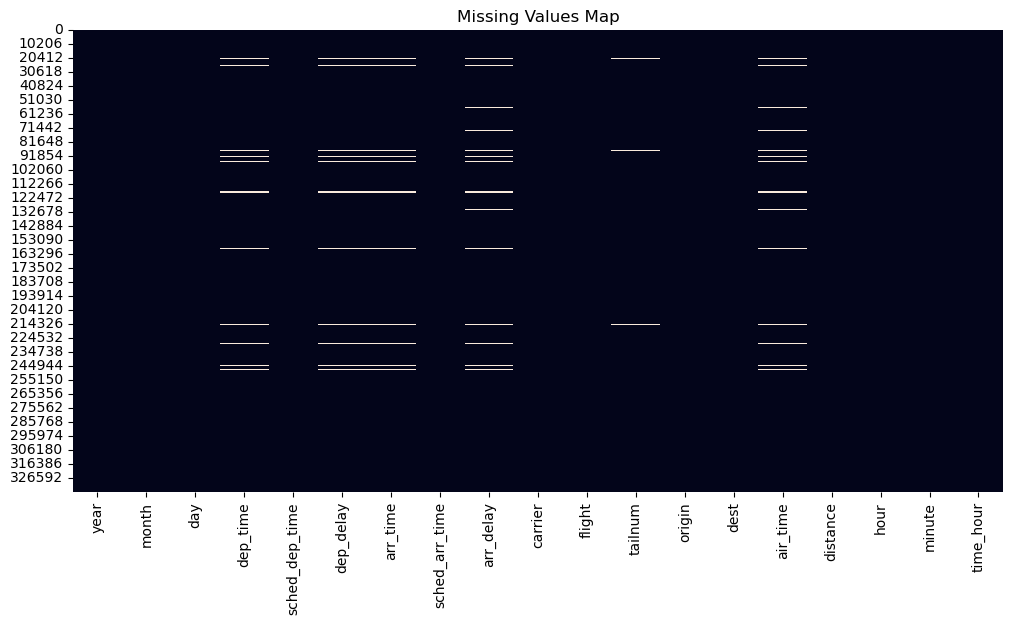

In [7]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(),cbar=False)
plt.title("Missing Values Map")
plt.show()

Missing values are primarily concentrated in departure time, arrival time, delay, and air-time variables. These incomplete records may affect delay and flight-performance analysis and therefore require appropriate handling during data preprocessing.

Duplicate check

In [8]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


Data cleaning

In [9]:
df_clean=df.copy()

#datetime columns
date_cols=["time_hour"]
for col in date_cols:
    df_clean[col]=pd.to_datetime(df_clean[col],errors="coerce")

#empty tail numbers with NaN
df_clean["tailnum"]=df_clean["tailnum"].replace("",np.nan)

#duplicates
df_clean=df_clean.drop_duplicates().reset_index(drop=True)

print("Cleaned shape;",df_clean.shape)

Cleaned shape; (336776, 19)


Feature engineering

In [10]:
# Extract date parts from time_hour
df_clean["year"] = df_clean["time_hour"].dt.year
df_clean["month"] = df_clean["time_hour"].dt.month
df_clean["day"] = df_clean["time_hour"].dt.day
df_clean["weekday"] = df_clean["time_hour"].dt.day_name()
df_clean["hour"] = df_clean["time_hour"].dt.hour

# Delay flags
df_clean["dep_delayed_15m"] = (df_clean["dep_delay"] >= 15).astype("Int64")
df_clean["arr_delayed_15m"] = (df_clean["arr_delay"] >= 15).astype("Int64")

# Flight speed in miles per hour
df_clean["speed_mph"] = (df_clean["distance"] / df_clean["air_time"]) * 60
df_clean["speed_mph"] = df_clean["speed_mph"].replace([np.inf, -np.inf], np.nan)

# Delay difference
df_clean["delay_gap"] = df_clean["arr_delay"] - df_clean["dep_delay"]

df_clean[["year", "month", "weekday", "hour", "speed_mph", "delay_gap"]].head()

,year,month,weekday,hour,speed_mph,delay_gap
0,2013,1,Tuesday,10,370.044053,9.0
1,2013,1,Tuesday,10,374.273128,16.0
2,2013,1,Tuesday,10,408.375000,31.0
3,2013,1,Tuesday,10,516.721311,-17.0
4,2013,1,Tuesday,11,394.137931,-19.0


EDA (Exploratory Data Analysis)

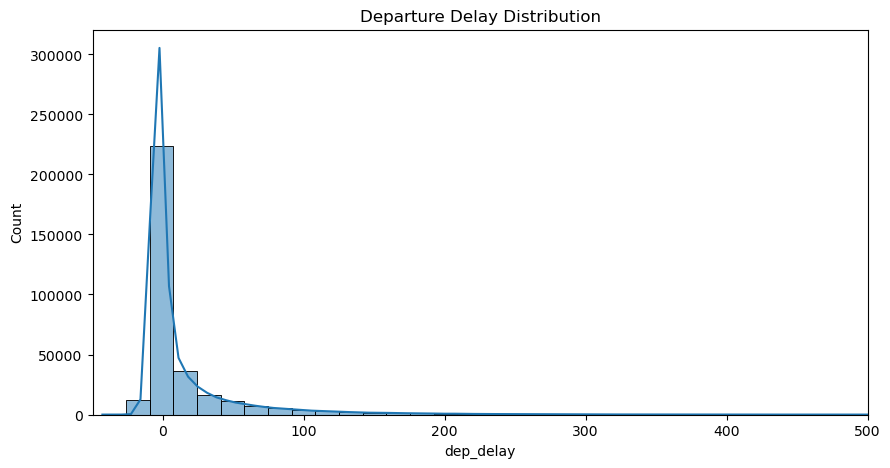

In [11]:
# Distribution of departure delay
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["dep_delay"], bins=80, kde=True)
plt.title("Departure Delay Distribution")
plt.xlim(-50, 500)
plt.show()

Most flights have little to no departure delay, while the distribution is strongly right-skewed. Most delays are under 200 minutes, with a small number of flights experiencing much longer delays.

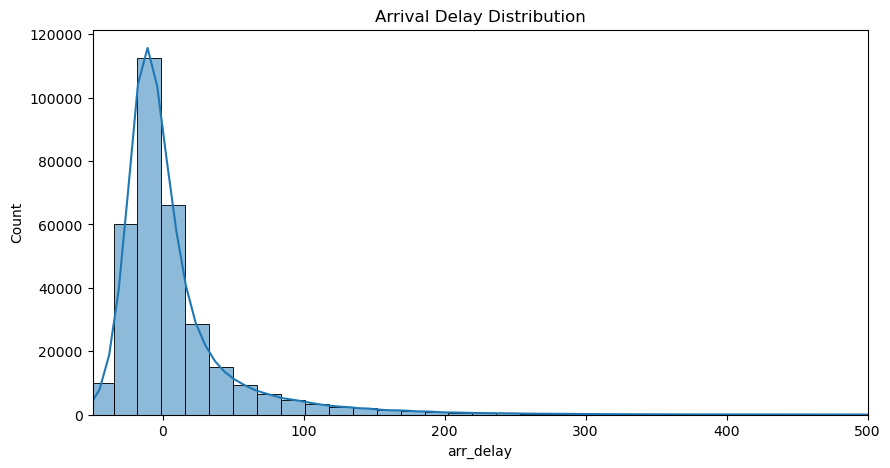

In [12]:
# Distribution of arrival delay
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["arr_delay"], bins=80, kde=True)
plt.title("Arrival Delay Distribution")
plt.xlim(-50, 500)
plt.show()

Arrival delays are generally more dispersed than departure delays, with a longer right tail indicating that some flights experience substantially longer delays upon arrival.

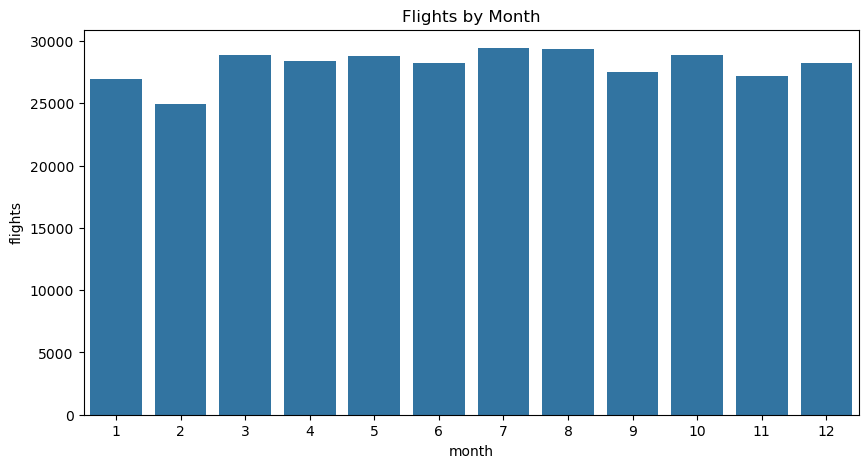

In [13]:
# Flights per month
monthly_flights = df_clean.groupby("month").size().reset_index(name="flights")

plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_flights, x="month", y="flights")
plt.title("Flights by Month")
plt.show()

Flight volume remains relatively consistent across the year, with July and August recording the highest number of flights. February has the lowest flight volume, while the remaining months show relatively stable traffic.

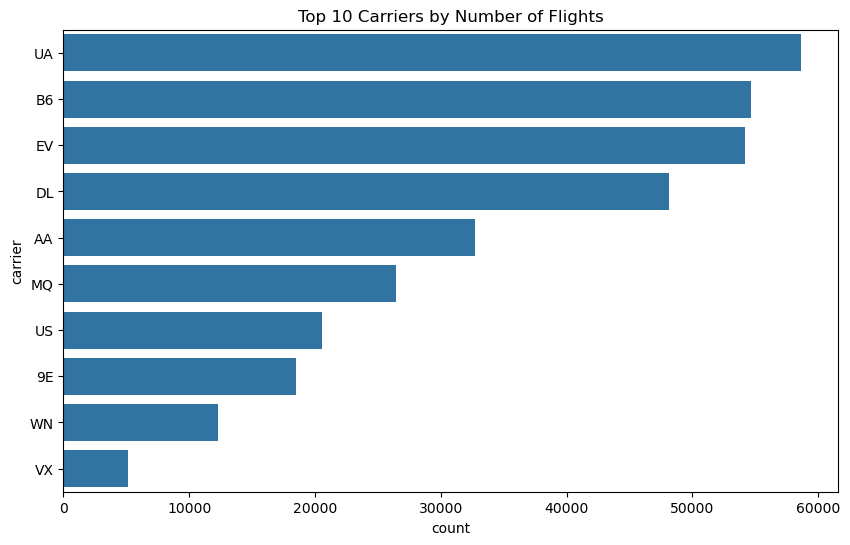

In [14]:
top_carriers = df_clean["carrier"].value_counts().head(10).index

plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean[df_clean["carrier"].isin(top_carriers)], y="carrier", order=top_carriers)
plt.title("Top 10 Carriers by Number of Flights")
plt.show()

The analysis shows that United Airlines (UA) has the highest number of flights among the carriers in the dataset.

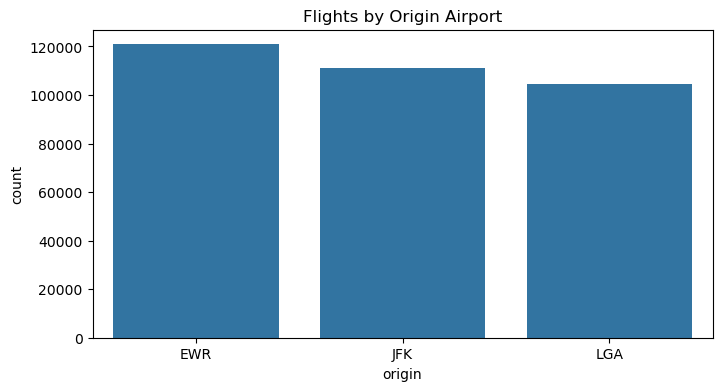

In [15]:
top_origins = df_clean["origin"].value_counts().index

plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x="origin", order=top_origins)
plt.title("Flights by Origin Airport")
plt.show()

EWR handles the highest number of flights among the three airports, followed by JFK and LGA. This indicates that EWR has the highest flight traffic volume in the dataset.

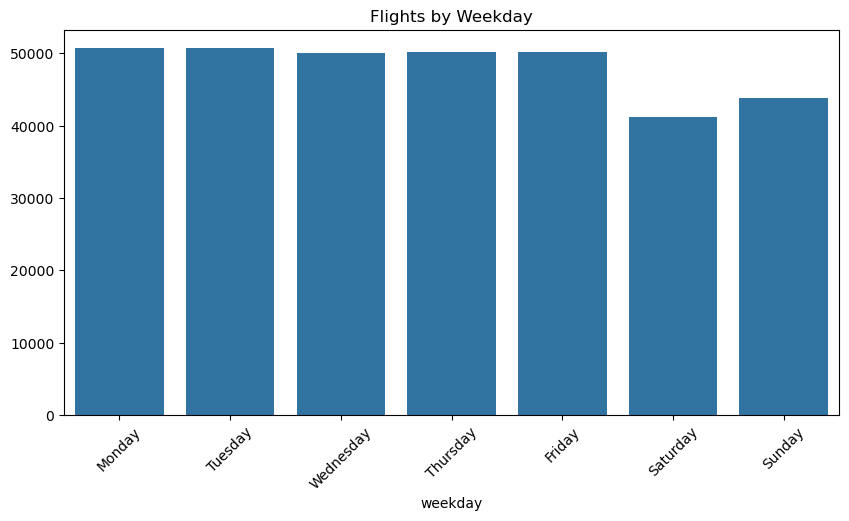

In [16]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_counts = df_clean["weekday"].value_counts().reindex(weekday_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values)
plt.xticks(rotation=45)
plt.title("Flights by Weekday")
plt.show()

Flight volume is relatively consistent from Monday to Friday, while Saturday has the lowest number of flights. Sunday also shows lower flight volume compared with weekdays.

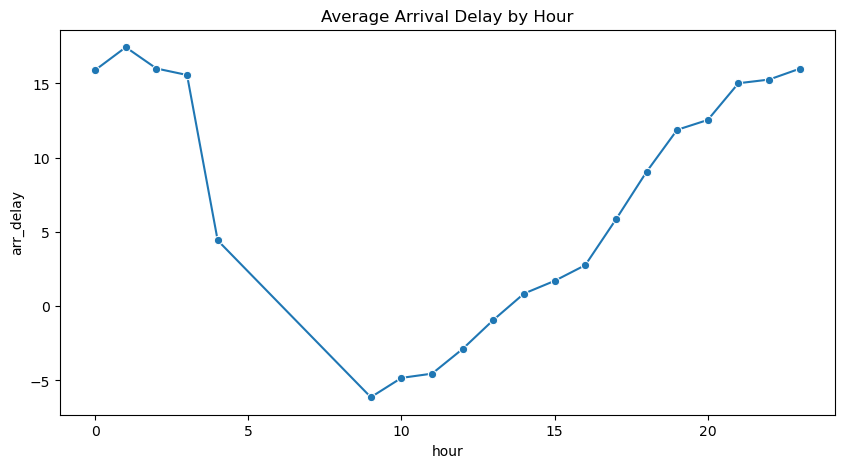

In [17]:
hour_delay = df_clean.groupby("hour")["arr_delay"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hour_delay, x="hour", y="arr_delay", marker="o")
plt.title("Average Arrival Delay by Hour")
plt.show()

In [18]:
#Carrier delay analysis

carrier_delay = (
    df_clean.groupby("carrier")[["dep_delay", "arr_delay"]]
    .mean()
    .sort_values("arr_delay", ascending=False)
    .reset_index()
)

display(carrier_delay.head(10))

,carrier,dep_delay,arr_delay
0,F9,20.215543,21.920705
1,FL,18.726075,20.115906
2,EV,19.955390,15.796431
3,YV,18.996330,15.556985
4,OO,12.586207,11.931034
5,MQ,10.552041,10.774733
6,WN,17.711744,9.649120
7,B6,13.022522,9.457973
8,9E,16.725769,7.379669
9,UA,12.106073,3.558011


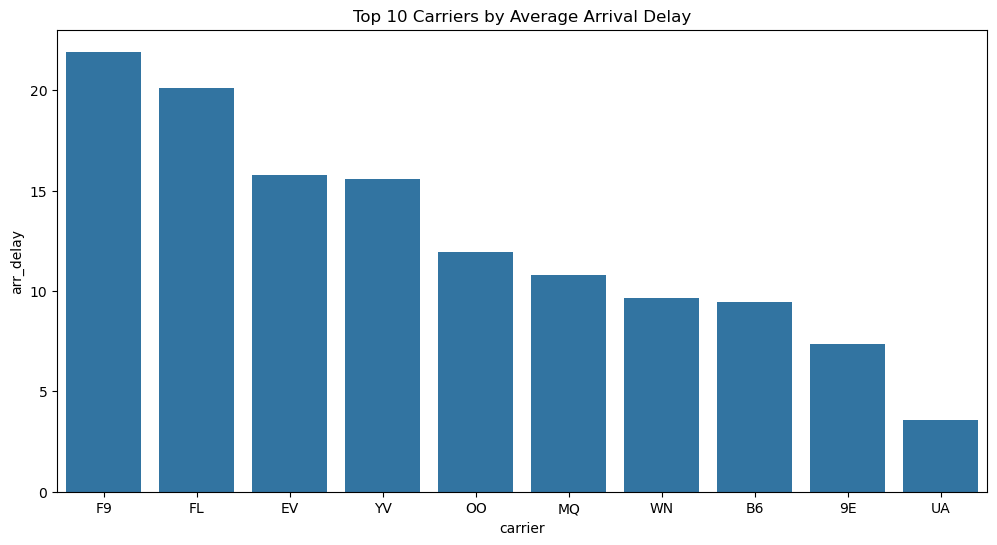

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(data=carrier_delay.head(10), x="carrier", y="arr_delay")
plt.title("Top 10 Carriers by Average Arrival Delay")
plt.show()

F9 has the highest average arrival delay among the top 10 carriers, followed by FL, while UA has the lowest average arrival delay. This indicates noticeable differences in delay performance across airlines.

In [20]:
origin_delay = (
    df_clean.groupby("origin")[["dep_delay", "arr_delay"]]
    .mean()
    .reset_index()
)

origin_delay

,origin,dep_delay,arr_delay
0,EWR,15.107954,9.107055
1,JFK,12.112159,5.551481
2,LGA,10.346876,5.783488


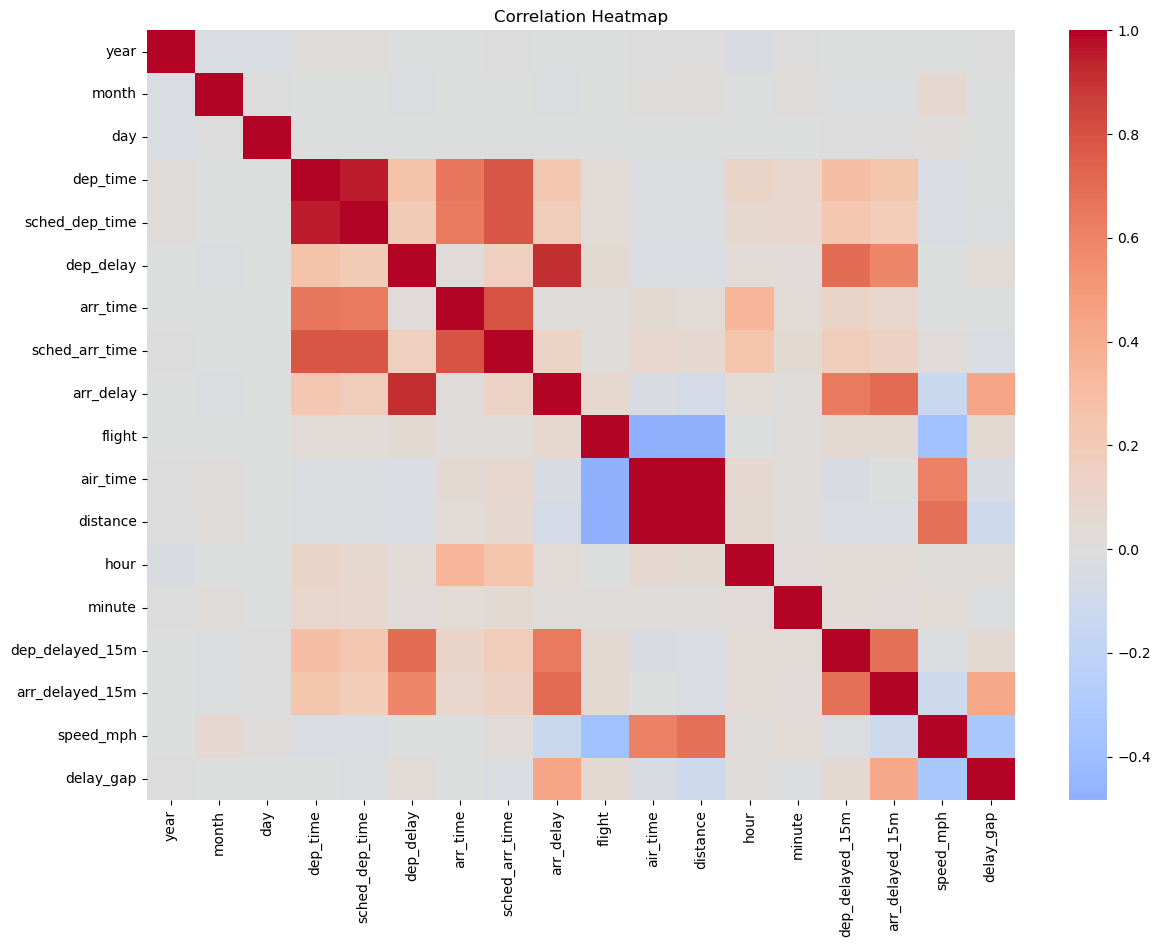

In [21]:
#Correlation analysis

numeric_cols = df_clean.select_dtypes(include=np.number).columns
corr = df_clean[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


In [22]:
#Merge with airlines table

airlines_df = airlines.copy()
df_air = df_clean.merge(airlines_df, on="carrier", how="left")

display(df_air[["carrier", "name", "dep_delay", "arr_delay"]].head())

,carrier,name,dep_delay,arr_delay
0,UA,United Air Lines Inc.,2.0,11.0
1,UA,United Air Lines Inc.,4.0,20.0
2,AA,American Airlines Inc.,2.0,33.0
3,B6,JetBlue Airways,-1.0,-18.0
4,DL,Delta Air Lines Inc.,-6.0,-25.0


In [23]:
carrier_name_delay = (
    df_air.groupby("name")[["dep_delay", "arr_delay"]]
    .mean()
    .sort_values("arr_delay", ascending=False)
    .reset_index()
)

display(carrier_name_delay.head(10))


,name,dep_delay,arr_delay
0,Frontier Airlines Inc.,20.215543,21.920705
1,AirTran Airways Corporation,18.726075,20.115906
2,ExpressJet Airlines Inc.,19.955390,15.796431
3,Mesa Airlines Inc.,18.996330,15.556985
4,SkyWest Airlines Inc.,12.586207,11.931034
5,Envoy Air,10.552041,10.774733
6,Southwest Airlines Co.,17.711744,9.649120
7,JetBlue Airways,13.022522,9.457973
8,Endeavor Air Inc.,16.725769,7.379669
9,United Air Lines Inc.,12.106073,3.558011


In [24]:
airports_df = airports.copy()

origin_airports = airports_df.rename(columns={
    "name": "origin_airport_name",
    "lat": "origin_lat",
    "lon": "origin_lon",
    "alt": "origin_alt"
})[["faa", "origin_airport_name", "origin_lat", "origin_lon", "origin_alt", "tz", "dst", "tzone"]]

df_airport = df_clean.merge(origin_airports, left_on="origin", right_on="faa", how="left")

display(df_airport[["origin", "origin_airport_name", "origin_lat", "origin_lon"]].head())


,origin,origin_airport_name,origin_lat,origin_lon
0,EWR,Newark Liberty Intl,40.692500,-74.168667
1,LGA,La Guardia,40.777245,-73.872608
2,JFK,John F Kennedy Intl,40.639751,-73.778925
3,JFK,John F Kennedy Intl,40.639751,-73.778925
4,LGA,La Guardia,40.777245,-73.872608


In [25]:
#Weather analysis

weather_df = weather.copy()
weather_df["time_hour"] = pd.to_datetime(weather_df["time_hour"], errors="coerce")

# Merge on origin airport and time
df_weather = df_clean.merge(
    weather_df,
    on=["origin", "time_hour"],
    how="left",
    suffixes=("", "_weather")
)

display(df_weather[["origin", "time_hour", "temp", "wind_speed", "visib", "precip"]].head())

,origin,time_hour,temp,wind_speed,visib,precip
0,EWR,2013-01-01 10:00:00+00:00,39.02,12.65858,10.0,0.0
1,LGA,2013-01-01 10:00:00+00:00,39.92,14.96014,10.0,0.0
2,JFK,2013-01-01 10:00:00+00:00,39.02,14.96014,10.0,0.0
3,JFK,2013-01-01 10:00:00+00:00,39.02,14.96014,10.0,0.0
4,LGA,2013-01-01 11:00:00+00:00,39.92,16.11092,10.0,0.0


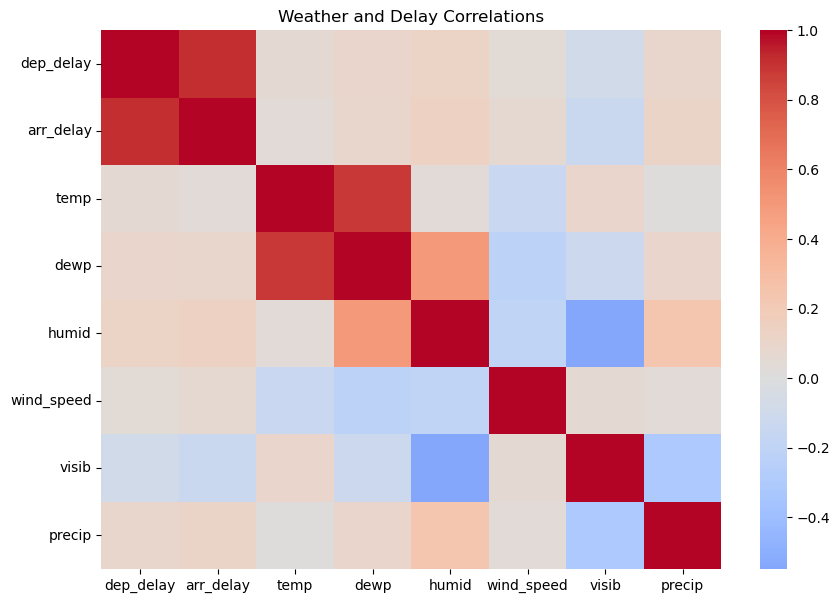

In [26]:
weather_corr_cols = [c for c in ["dep_delay", "arr_delay", "temp", "dewp", "humid", "wind_speed", "visib", "precip"] if c in df_weather.columns]
weather_corr = df_weather[weather_corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(weather_corr, annot=False, cmap="coolwarm", center=0)
plt.title("Weather and Delay Correlations")
plt.show()

Weather variables show relatively weak correlations with departure and arrival delays. Temperature and dew point have a stronger positive relationship with each other, while visibility shows a negative relationship with humidity and a weaker relationship with flight delays.

### AIRPORTS

In [27]:
airports_df = airports.copy()

display(airports_df.head())
airports_df.info()

,faa,name,lat,lon,alt,tz,dst,tzone
0,04G,Lansdowne Airport,41.130472,-80.619583,1044,-5,A,America/New_York
1,06A,Moton Field Municipal Airport,32.460572,-85.680028,264,-6,A,America/Chicago
2,06C,Schaumburg Regional,41.989341,-88.101243,801,-6,A,America/Chicago
3,06N,Randall Airport,41.431912,-74.391561,523,-5,A,America/New_York
4,09J,Jekyll Island Airport,31.074472,-81.427778,11,-5,A,America/New_York


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   faa     1458 non-null   object 
 1   name    1458 non-null   object 
 2   lat     1458 non-null   float64
 3   lon     1458 non-null   float64
 4   alt     1458 non-null   int64  
 5   tz      1458 non-null   int64  
 6   dst     1458 non-null   object 
 7   tzone   1455 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 91.3+ KB


### Basic data understanding

In [28]:
airports_df.isna().sum()

faa      0
name     0
lat      0
lon      0
alt      0
tz       0
dst      0
tzone    3
dtype: int64

In [29]:
airports_df.duplicated().sum()

np.int64(0)

In [30]:
airports_df["dst"].value_counts()

dst
A    1388
U      47
N      23
Name: count, dtype: int64

In [31]:
airports_df["faa"].nunique()

1458

In [32]:
airports_df["tzone"].nunique()

9

In [33]:
airports_df[["lat", "lon", "alt"]].describe()

,lat,lon,alt
count,1458.000000,1458.000000,1458.000000
mean,41.648008,-103.392289,1001.415638
std,10.449509,29.843118,1523.626105
min,19.721375,-176.646000,-54.000000
25%,34.257539,-119.185652,70.250000
50%,40.087722,-94.661854,473.000000
75%,45.067150,-82.516717,1062.500000
max,72.270833,174.113620,9078.000000


In [34]:
airports_df["name"].value_counts().head(10)

name
Municipal Airport               5
All Airports                    3
Penn Station                    2
Marshfield Municipal Airport    2
Executive                       2
Capital City Airport            2
Regional Airport                2
Grand Canyon West Airport       2
Shelby County Airport           2
Plymouth Municipal Airport      2
Name: count, dtype: int64

In [35]:
airports_df[["lat","lon"]].corr()

,lat,lon
lat,1.000000,-0.597538
lon,-0.597538,1.000000


### Number of flights departed from each airport

In [36]:
df_clean["origin"].value_counts()

origin
EWR    120835
JFK    111279
LGA    104662
Name: count, dtype: int64

In [37]:
df_clean["dest"].value_counts().head(10)

dest
ORD    17283
ATL    17215
LAX    16174
BOS    15508
MCO    14082
CLT    14064
SFO    13331
FLL    12055
MIA    11728
DCA     9705
Name: count, dtype: int64

In [39]:
df_clean = df_clean.drop(
    columns=[
        "faa_x", "name_x", "lat_x", "lon_x", "alt_x", "tz_x", "dst_x", "tzone_x",
        "faa_y", "name_y", "lat_y", "lon_y", "alt_y", "tz_y", "dst_y", "tzone_y"
    ], errors="ignore"
)

In [ ]:
df_clean.columns

In [ ]:
df_clean= df_clean.merge(airports_df,left_on="origin",right_on="faa",how = "left")
df_clean[["origin", "name", "lat", "lon", "alt"]].head()

In [ ]:
df_clean[["name", "lat", "lon", "alt"]].isna().sum()

### Airport Altitude Analysis
La Guardia has the highest average altitude among the three origin airports.

In [ ]:
df_clean.groupby("name")["alt"].mean().sort_values(ascending=False).head(10)

### Flight Volume by Origin Airport
Newark Liberty Intl has the highest number of departures among the three origin airports.

In [ ]:
df_clean["name"].value_counts()

### Destination Airport Data Quality

In [ ]:
df_clean = df_clean.merge(airports_df,left_on="dest",right_on="faa",how="left",suffixes=("", "_dest"))

In [ ]:
df_clean[["dest", "name_dest", "lat_dest", "lon_dest", "alt_dest"]].head()

In [ ]:
df_clean[["name_dest", "lat_dest", "lon_dest", "alt_dest"]].isna().sum()

In [ ]:
df_clean[df_clean["name_dest"].isna()]["dest"].value_counts().head(20)

The destination airport merge identified 7,602 flights without matching airport details. These correspond to four destination codes.
These records are retained because the flights themselves are valid, only the corresponding airport details are unavailable in the airports dataset.

### Flight Volume by Destination Airport

In [ ]:
df_clean["name_dest"].value_counts().head(10)

### Flight Distance Analysis

In [ ]:
df_clean["distance"].describe()

Flight routes average about 1,040 miles, with a median of 872 miles, indicating that some longer routes increase the overall average.

### Flight Distance by Origin

In [ ]:
df_clean.groupby("name")["distance"].mean().sort_values(ascending=False)

JFK serves the longest average routes (1,266 miles), while LGA serves the shortest (780 miles).

### Departure Delay by Origin

In [ ]:
df_clean.groupby("name")["dep_delay"].mean().sort_values(ascending=False)

EWR has the highest average departure delay, while LGA has the lowest.

### Arrival Delay by Origin

In [ ]:
df_clean.groupby("name")["arr_delay"].mean().sort_values(ascending=False)

EWR has the highest average arrival delay, nearly 3.6 minutes higher than JFK.

### Average speed by origin airport

In [ ]:
df_clean.groupby("name")["speed_mph"].mean().sort_values(ascending=False)

In [ ]:
df_clean.groupby("name")["alt"].mean()

### Airport Performance Summary
EWR handles the most flights and has the highest average delays, while JFK serves the longest routes and LGA has the lowest departure delays.

In [ ]:
airport_summary = df_clean.groupby("name").agg(
    flights=("flight", "count"),
    avg_distance=("distance", "mean"),
    avg_dep_delay=("dep_delay", "mean"),
    avg_arr_delay=("arr_delay", "mean")
).round(2)

airport_summary

### AIRLINES

Basic data understanding

In [ ]:
airlines_df = airlines.copy()

display(airlines_df.head())
airlines_df.info()

In [ ]:
airlines_df.isna().sum()

In [ ]:
airlines_df.duplicated().sum()

In [ ]:
airlines_df

In [ ]:
df_clean["carrier"].value_counts()

In [ ]:
df_clean = df_clean.merge(airlines_df,on="carrier",how="left",suffixes=("", "_airline"))

df_clean[["carrier", "name_airline"]].head()

### Flight volume by airline

In [ ]:
df_clean["name_airline"].value_counts()

United Air Lines has the highest number of flights, followed by JetBlue and ExpressJet.

### Average Departure and Arrival Delay by Airline

In [ ]:
airline_delay = df_clean.groupby("name_airline").agg(
    avg_dep_delay=("dep_delay", "mean"),
    avg_arr_delay=("arr_delay", "mean")
).round(2)

airline_delay.sort_values("avg_dep_delay", ascending=False)

Frontier Airlines has the highest average departure delay (20.22 minutes) and arrival delay (21.92 minutes) among the airlines in the dataset.

### Airline On-Time Performance

In [ ]:
airline_on_time = df_clean.groupby("name_airline").agg(
    total_flights=("flight", "count"),
    delayed_flights=("dep_delayed_15m", "sum"))

airline_on_time["delay_rate_%"] = (
    airline_on_time["delayed_flights"] /
    airline_on_time["total_flights"] * 100
).round(2)

airline_on_time.sort_values("delay_rate_%", ascending=False)

In [ ]:
airline_on_time_sorted = airline_on_time.sort_values(
    "delay_rate_%", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=airline_on_time_sorted.reset_index(),
    x="delay_rate_%",
    y="name_airline")

plt.title("Departure Delay Rate by Airline")
plt.xlabel("Delay Rate (%)")
plt.ylabel("Airline")
plt.show()

ExpressJet Airlines has the highest departure delay rate at 29.52%, with 15,991 of its 54,173 flights delayed by 15 minutes or more.

### PLANES

Basic Data Understanding

In [ ]:
planes_df = planes.copy()

display(planes_df.head())
planes_df.info()

In [ ]:
planes_df.isna().sum()

In [ ]:
planes_df.duplicated().sum()

In [ ]:
planes_df["type"].value_counts()

In [ ]:
planes_df["manufacturer"].value_counts()

Boeing is the most common manufacturer, with 1,630 aircraft records.

### Aircraft Seating Capacity

In [ ]:
planes_df["seats"].describe()

The aircraft have an average capacity of about 154 seats, with a median of 149 seats. Maximum capacity is 450 seats.

### Aircraft Engine Distribution

In [ ]:
planes_df["engines"].value_counts()

The planes dataset is dominated by two-engine aircraft, with 3,288 of the 3,322 aircraft records having two engines.

### Aircraft Age Analysis

In [ ]:
planes_df["age"] = 2013 - planes_df["year"]
planes_df["age"].describe()

The aircraft have an average age of about 12.5 years, with a median age of 12 years. Half of the aircraft are between 8 and 16 years old.

In [ ]:
planes_df.groupby("manufacturer")["seats"].mean().sort_values(ascending=False).head(10)

Some manufacturers are listed under multiple names, so we shouldn't treat these as perfect indicators.

In [ ]:
df_clean = df_clean.merge(
    planes_df,
    on="tailnum",
    how="left",
    suffixes=("", "_plane")
)

Used tailnum to find out which aircraft were actually used in the flights

In [ ]:
df_clean[["tailnum", "manufacturer", "model", "seats"]].head()

In [ ]:
df_clean["manufacturer"].value_counts().head(10)

This tells us Boeing aircraft were used in the most flights, followed by Embraer and Airbus.

### Aircraft Manufacturer and Delay Analysis

In [ ]:
manufacturer_summary = df_clean.groupby("manufacturer").agg(
    flights=("flight", "count"),
    avg_dep_delay=("dep_delay", "mean"),
    avg_arr_delay=("arr_delay", "mean")
).round(2)

manufacturer_summary.sort_values("flights", ascending=False).head(10)

Boeing aircraft account for the highest number of flights (82,912), while Embraer aircraft show a higher average departure delay of 16.84 minutes across 66,068 flights.

In [ ]:
df_clean[["age", "dep_delay"]].corr()

### Aircraft Model Analysis

In [ ]:
df_clean["model"].value_counts().head(10)

The A320-232 is the most frequently used aircraft model in the dataset, with 45,831 flights.

In [ ]:
df_clean.groupby("seats")["dep_delay"].mean().sort_values(ascending=False).head(10)

In [ ]:
df_clean["seats"].value_counts().head(10)

### Aircraft Seating Capacity and Departure Delay

In [ ]:
seat_delay = df_clean.groupby("seats").agg(
    flights=("flight", "count"),
    avg_dep_delay=("dep_delay", "mean")).round(2)

seat_delay[seat_delay["flights"] >= 1000].sort_values("avg_dep_delay", ascending=False)

In [ ]:
seat_delay_filtered = seat_delay[seat_delay["flights"] >= 1000]

plt.figure(figsize=(10,6))

sns.barplot(
    data=seat_delay_filtered.reset_index(),
    x="seats",
    y="avg_dep_delay"
)

plt.title("Average Departure Delay by Aircraft Seat Capacity")
plt.xlabel("Number of Seats")
plt.ylabel("Average Departure Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

Aircraft with 55 seats have the highest average departure delay (19.19 minutes) among seat capacities with at least 1,000 flights, followed closely by 80-seat and 95-seat aircraft.

### WEATHER

In [ ]:
weather_df = weather.copy()

display(weather_df.head())
weather_df.info()

Basic Data Understanding

In [ ]:
weather_df.isna().sum()

In [ ]:
weather_df.duplicated().sum()

In [ ]:
weather_df["time_hour"] = pd.to_datetime(
    weather_df["time_hour"],
    errors="coerce"
)

weather_df.info()

In [ ]:
weather_df.describe().T

In [ ]:
weather_df.groupby("origin").agg(
    avg_temp=("temp", "mean"),
    avg_humidity=("humid", "mean"),
    avg_wind_speed=("wind_speed", "mean"),
    avg_visibility=("visib", "mean"),
    avg_precip=("precip", "mean")).round(2)

In [41]:
weather_monthly = weather_df.groupby("month").agg(
    avg_temp=("temp", "mean"),
    avg_humidity=("humid", "mean"),
    avg_wind_speed=("wind_speed", "mean"),
    avg_visibility=("visib", "mean"),
    avg_precip=("precip", "mean")).round(2)

weather_monthly

,avg_temp,avg_humidity,avg_wind_speed,avg_visibility,avg_precip
month,,,,,
1,35.64,60.98,11.18,8.62,0.00
2,34.27,62.19,12.67,8.80,0.00
3,39.88,57.50,12.93,9.32,0.00
4,51.75,55.81,11.10,9.55,0.00
5,61.80,65.52,9.52,8.88,0.01
6,72.18,67.33,10.26,9.32,0.01
7,80.07,66.90,9.58,9.59,0.00
8,74.47,64.65,8.61,9.70,0.00
9,67.37,62.99,8.91,9.66,0.00


### Monthly Weather Analysis

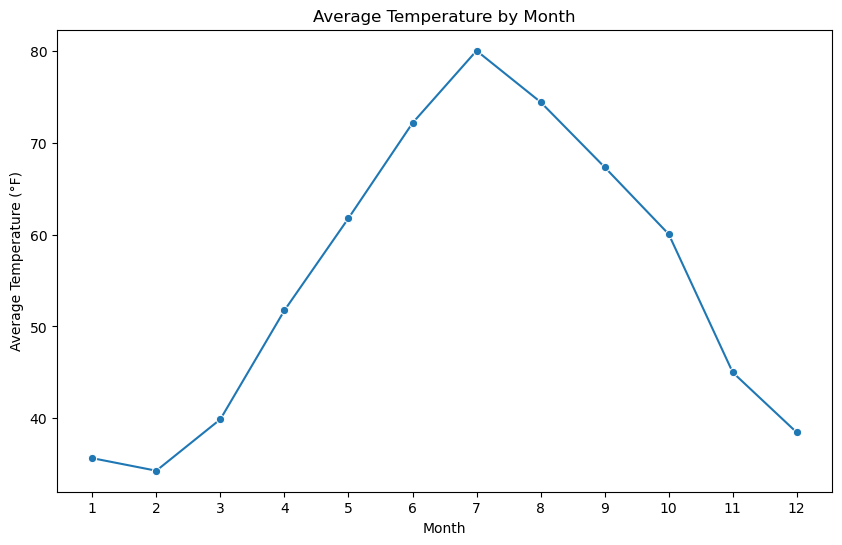

In [42]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=weather_monthly,
    x=weather_monthly.index,
    y="avg_temp",
    marker="o"
)

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°F)")
plt.xticks(range(1,13))
plt.show()

This gives us a clear seasonal pattern.
- July has the highest average temperature: 80.07°F
- February has the highest average wind speed: 12.67
- December has the highest humidity: 67.22%
- August has the highest visibility: 9.70 miles
- Precipitation remains very low throughout the year.

In [43]:
df_clean["time_hour"].head()

0   2013-01-01 10:00:00+00:00
1   2013-01-01 10:00:00+00:00
2   2013-01-01 10:00:00+00:00
3   2013-01-01 10:00:00+00:00
4   2013-01-01 11:00:00+00:00
Name: time_hour, dtype: datetime64[ns, UTC]

In [44]:
weather_df["time_hour"].head()

0   2013-01-01 06:00:00+00:00
1   2013-01-01 07:00:00+00:00
2   2013-01-01 08:00:00+00:00
3   2013-01-01 09:00:00+00:00
4   2013-01-01 10:00:00+00:00
Name: time_hour, dtype: datetime64[ns, UTC]

In [ ]:
df_clean = df_clean.merge(
    weather_df,
    on=["origin", "time_hour"],
    how="left",
    suffixes=("", "_weather"))

df_clean[["origin","time_hour","temp","humid","wind_speed","precip","visib"]].head()

### Weather and Departure Delay

In [ ]:
weather_delay_corr = df_clean[
    ["dep_delay", "temp", "humid", "wind_speed", "precip", "pressure", "visib"]
].corr()["dep_delay"].sort_values(ascending=False)

weather_delay_corr

### Weather Variables and Departure Delay Correlation

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_clean[
        ["dep_delay", "temp", "humid", "wind_speed", "precip", "pressure", "visib"]
    ].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Weather Variables and Departure Delay Correlation")
plt.show()

The heatmap shows that weather variables have only weak linear relationships with departure delay. Humidity has the strongest positive correlation with departure delay (0.12), while pressure has the strongest negative correlation (-0.11).

In [ ]:
#weather conditions vs delayed flights

weather_delay = df_clean.groupby("dep_delayed_15m").agg(
    avg_temp=("temp", "mean"),
    avg_humidity=("humid", "mean"),
    avg_wind_speed=("wind_speed", "mean"),
    avg_visibility=("visib", "mean"),
    avg_precip=("precip", "mean")).round(2)

weather_delay

In [ ]:
#weather by airport

weather_airport = weather_df.groupby("origin").agg(
    avg_temp=("temp", "mean"),
    avg_humidity=("humid", "mean"),
    avg_wind_speed=("wind_speed", "mean"),
    avg_visibility=("visib", "mean"),
    avg_precip=("precip", "mean")).round(2)

weather_airport

### Monthly Weather and Departure Delay

In [ ]:
weather_delay_monthly = df_clean.groupby("month").agg(
    avg_dep_delay=("dep_delay", "mean"),
    avg_temp=("temp", "mean"),
    avg_humidity=("humid", "mean"),
    avg_wind_speed=("wind_speed", "mean")
).round(2)

weather_delay_monthly

Average departure delays are highest during June and July, when average temperatures are also highest. Delays are lowest in October and November.

In [ ]:
df_clean[["temp", "humid", "wind_speed", "precip", "pressure", "visib"]].isna().sum()

In [ ]:
df_clean.shape

In [ ]:
df_clean.columns.tolist()

### KEY BUSINESS INSIGHTS

### 1. Which month had the highest traffic?

In [ ]:
monthly_traffic= df_clean.groupby("month")["flight"].count()
monthly_traffic.sort_values(ascending=False)

July had the highest flight traffic, with 29,428 flights recorded during the month.

### 2. Which carrier had the worst average delay?

In [ ]:
carrier_delay = df_clean.groupby("name_airline")["dep_delay"].mean()

carrier_delay.sort_values(ascending=False)

Frontier Airlines Inc. had the highest average departure delay at 20.22 minutes among the carriers in the dataset.

### 3. Which origin airport performed best?

In [ ]:
origin_delay = df_clean.groupby("origin")["dep_delay"].mean()

origin_delay.sort_values()

LGA had the lowest average departure delay, followed by JFK and EWR.

### 4. Which hour is most delay-prone?

In [ ]:
hour_delay = df_clean.groupby("hour")["dep_delay"].mean()

hour_delay.sort_values(ascending=False)

Flights scheduled around midnight have the highest average departure delay. Delay levels are also high during the late-night hours.

### 5. Do weather conditions affect delays?

The heatmap above shows that weather variables have only weak linear relationships with departure delay. Humidity has the strongest positive correlation with departure delay (0.12), while pressure has the strongest negative correlation (-0.11).

### 6. Which destination had the highest number of flights?

In [ ]:
destination_traffic = df_clean.groupby("dest")["flight"].count()

destination_traffic.sort_values(ascending=False).head(10)

ORD (Chicago O'Hare) was the most frequently served destination, with 17,283 flights.

### 7. Which day of the week had the most flights?

In [ ]:
weekday_traffic = df_clean.groupby("weekday")["flight"].count()

weekday_traffic.sort_values(ascending=False)

Monday had the highest number of flights, with 50,709 flights, while Saturday had the lowest with 41,278 flights.

### 8. Which origin airport handled the most flights? 

In [ ]:
origin_traffic = df_clean.groupby("origin")["flight"].count()

origin_traffic.sort_values(ascending=False)

EWR handled the highest number of flights, with 120,835 flights, followed by JFK and LGA.

### 9. Which aircraft model was used for the most flights?

In [ ]:
aircraft_traffic = df_clean.groupby("model")["flight"].count()

aircraft_traffic.sort_values(ascending=False).head(10)

The A320-232 was the most frequently used aircraft model, accounting for 45,831 flights.

### 10. Which airline has the highest percentage of flights delayed by 15 minutes or more?

In [46]:
df_clean["name_airline"] = df_clean["carrier"].map(
    airlines_df.set_index("carrier")["name"]
)

In [48]:
airline_delay_rate = df_clean.groupby("name_airline").agg(
    total_flights=("flight", "count"),
    delayed_flights=("dep_delayed_15m", "sum"))

airline_delay_rate["delay_rate_%"] = (
    airline_delay_rate["delayed_flights"]
    / airline_delay_rate["total_flights"] * 100).round(2)

airline_delay_rate.sort_values(
    "delay_rate_%", ascending=False)

,total_flights,delayed_flights,delay_rate_%
name_airline,,,
ExpressJet Airlines Inc.,54173,15991,29.52
Frontier Airlines Inc.,685,202,29.49
Southwest Airlines Co.,12275,3352,27.31
AirTran Airways Corporation,3260,882,27.06
Mesa Airlines Inc.,601,160,26.62
Endeavor Air Inc.,18460,4563,24.72
JetBlue Airways,54635,12711,23.27
United Air Lines Inc.,58665,12655,21.57
Envoy Air,26397,5481,20.76


ExpressJet Airlines Inc. had the highest departure delay rate at 29.52%, with 15,991 of its 54,173 flights delayed by 15 minutes or more.